In [1]:
# ============================================================
#  SPECIES = "mouse"   <-- this notebook is the MOUSE entrypoint
# ============================================================
SPECIES = "mouse"

# Mouse MPTP VBI-SBI 14-step Pipeline (115 region)

One cell per pipeline step.

| Step | Description |
|------|-------------|
| 1  | Data split (train / val / test) |
| 2  | WC simulation |
| 3  | Feature extraction summary |
| 4  | Feature preprocessing (z-score) |
| 5  | Feature embedding (FC PCA + FCD PCA) |
| 6  | Embedding quality check (PCA diagnostic) |
| 7  | Parameter preprocessing ([-1, 1]) |
| 8  | Stage 1 inference (SNPE-C) |
| 9  | Stage 1 analysis + MLP probing + SBC |
| 10 | Stage 2 parameter selection |
| 11 | Stage 2 inference |
| 12 | Stage 2 analysis |
| 13 | Model selection |
| 14 | Final test |

---

**전체를 한 번에 돌리고 싶다면**: 셀 단위 실행 대신 아래 두 줄로 끝납니다.

```python
from pipelines import run_pipeline
artifacts = run_pipeline()   # 또는 run_pipeline(n_sim=5000) 등
```

이 노트북은 같은 흐름을 14개 셀로 쪼개서 step별 figure / report를 inline으로 봅니다.


## Setup

**Parameters 섹션**의 `PipelineConfig(...)` 인자만 수정하세요.

커널 재시작 후 이 셀 하나만 실행하면:
- 모듈 자동 reload
- `config` 전체 동기화
- numpy / torch seed 설정
- `config.print_config()` 요약 출력

셀 출력은 노트북(`.ipynb`) 자체에 저장됩니다.

In [2]:
# =============================================================
# Setup — species config FIRST, then runtime knobs
# apply_species_config() MUST run before importing any pipeline module
# (same rule as main_mouse.py)
# =============================================================
import species_configs.mouse_config as _sc

# -- Data paths (set on species config before apply) --
_sc.DATA_DIR   = "/scratch/home/wog3597/vbi"
_sc.FC_PATH    = "/scratch/home/wog3597/vbi/MPTP_FC_115.mat"
_sc.SC_PATH    = "/scratch/home/wog3597/vbi/MPTP_SC_115.mat"
_sc.TSV_PATH   = "/scratch/home/wog3597/vbi/participants.tsv"
_sc.ATLAS_PATH = "/scratch/home/wog3597/vbi/atlas_115_labels.txt"
_sc.BOLD_PATH  = None
_sc.OUTPUT_DIR = "./output_mouse_mptp"

# -- Apply species scientific constants (N_REGIONS, timing, HRF, WC_FIXED,
#    velocity, STAGE1 params/priors) BEFORE any pipeline import --
import config
config.apply_species_config(_sc)

# -- Copy data paths into config (apply_species_config sets science only) --
config.DATA_DIR   = _sc.DATA_DIR
config.FC_PATH    = _sc.FC_PATH
config.SC_PATH    = _sc.SC_PATH
config.TSV_PATH   = _sc.TSV_PATH
config.ATLAS_PATH = _sc.ATLAS_PATH
config.BOLD_PATH  = _sc.BOLD_PATH
config.OUTPUT_DIR = _sc.OUTPUT_DIR

# -- Runtime knobs (edit here; NOT species-scientific constants) --
config.N_SIM        = 10_000
config.GPU_BATCH    = 10_000
config.N_TRAIN      = 6
config.N_VAL        = 0
config.N_TEST       = 2
config.SEED         = 42
config.SBI_DEVICE   = "cuda"
config.N_POSTERIOR  = 2000
config.N_SBC        = 200
config.N_TEST_RESIM = 10
config.NDE_HIDDEN     = 128
config.NDE_TRANSFORMS = 8
config.SELECTION_K  = 300
config.EMBED_DIM    = 128

# -- Init --
import os, warnings
warnings.filterwarnings("ignore")
os.makedirs(config.OUTPUT_DIR, exist_ok=True)

import numpy as np
np.random.seed(config.SEED)
try:
    import torch; torch.manual_seed(config.SEED)
except ImportError:
    pass

# Pipeline modules — imported AFTER apply_species_config
import data_loader
import evaluate
import inference
import simulator

config.print_config()
%matplotlib inline

  Mouse MPTP - VBI-SBI Pipeline (115 regions)
  Engine          : gpu (SBI: cuda)
  Split           : train=6 / val=0 / test=2
  Sim time        : T_end=300s, cut=60s
  Analysis BOLD   : 240 TR (TR=1.0s)
  Regions         : 115 (FC dim=6555, FCD dim=5)
  FC source       : col 1 (NaN -> 0, raw Pearson r)
  FCD source      : col 2 (summary stats: mean,std,q25,q50,q75)
  SC source       : col 1 (raw -> log1p + max-norm)
  Velocity        : 3.0 m/s
  Stage 1 params  : ['P', 'Q', 'g_e', 'g_i', 'c_ei']
  N_SIM           : 10000 per subject
  GPU batch       : 10000  (= N_SIM: 배치 1회)
  Embedding       : RegionTransformer (raw FC passthrough) -> 128
  Features        : FC=True FCD=False PSD=False
  Nuisance method : posterior_sample
  Mixed precision : True


## (Optional) 자원 진단 + 최적 GPU_BATCH 자동 탐색

GPU/RAM 자원을 점검하고, 짧은 시뮬을 돌려서 OOM 없는 최대 `GPU_BATCH`를 자동으로 찾습니다. 결과가 마음에 들면 Setup 셀의 `GPU_BATCH` 값을 권장값으로 바꾸고 다시 실행하세요.

- DECIMATE 값에 따라 RAM 사용량이 결정됩니다
- 일반적으로 1~3분 소요

import subprocess
import time
import numpy as np

# ── 1. 시스템 자원 확인 ──────────────────────────────────────
def gpu_info():
    r = subprocess.run(
        ["nvidia-smi",
         "--query-gpu=name,memory.total,memory.free,memory.used,utilization.gpu",
         "--format=csv,noheader,nounits"],
        capture_output=True, text=True)
    parts = [p.strip() for p in r.stdout.strip().split(",")]
    return {
        "name": parts[0],
        "vram_total_gb": float(parts[1]) / 1024,
        "vram_free_gb":  float(parts[2]) / 1024,
        "vram_used_gb":  float(parts[3]) / 1024,
        "util_pct":      float(parts[4]),
    }

def ram_info():
    r = subprocess.run(["free", "-g"], capture_output=True, text=True)
    for line in r.stdout.splitlines():
        if line.startswith("Mem:"):
            p = line.split()
            return {
                "total_gb": int(p[1]),
                "used_gb":  int(p[2]),
                "free_gb":  int(p[3]),
                "available_gb": int(p[6]),
            }
    return None

def cpu_count():
    import os
    return os.cpu_count()

g = gpu_info()
r = ram_info()
nc = cpu_count()

print("=" * 70)
print("  System resources")
print("=" * 70)
print(f"  GPU       : {g['name']}")
print(f"              VRAM total {g['vram_total_gb']:.1f} GB, "
      f"free {g['vram_free_gb']:.1f} GB, util {g['util_pct']:.0f}%")
print(f"  RAM       : total {r['total_gb']} GB, "
      f"available {r['available_gb']} GB")
print(f"  CPU       : {nc} cores")
print()

# ── 2. 현재 설정 + 메모리 추정 ───────────────────────────────
DT          = cfg.DT
DECIMATE    = cfg.DECIMATE
T_END       = cfg.T_END_MS
N_REG       = 115
N_SIM       = cfg.N_SIM
N_TRAIN     = cfg.N_TRAIN

stored_dt   = DT * DECIMATE
T_stored    = int(T_END / stored_dt)

# Streaming BW: only T_bold (TR-downsampled) frames stay in RAM
# T_bold = T_stored / (TR_sec * 1000 / stored_dt)
tr_ms = 1000.0  # config.TR_SEC * 1000
step_per_tr = max(1, int(round(tr_ms / stored_dt)))
T_bold = T_stored // step_per_tr

bytes_per_sim = T_bold * N_REG * 4  # streaming = ~100x less than full

print(f"  Stored dt  : {stored_dt:.1f} ms  "
      f"(DT={DT}, DECIMATE={DECIMATE})")
print(f"  T_stored   : {T_stored}  (was used as RAM size; not anymore)")
print(f"  T_bold     : {T_bold}  (streaming: only TR-downsampled BOLD in RAM)")
print(f"  RAM/sim    : {bytes_per_sim / 1e6:.3f} MB  (was "
      f"{T_stored * N_REG * 4 / 1e6:.1f} MB before streaming)")
print()

# Streaming makes RAM trivial; the actual bottleneck is now VRAM.
# We still cap by safe RAM for the unlikely case of huge T_bold.
safe_ram_gb  = r["available_gb"] * 0.7
max_batch_ram = int(safe_ram_gb * 1e9 / bytes_per_sim)
print(f"  Safe RAM   : {safe_ram_gb:.0f} GB "
      f"(70% of available)")
print(f"  Max batch by RAM : {max_batch_ram}")
print()

# ── 3. 짧은 시뮬로 OOM-free 최대 batch 자동 탐색 ─────────────
print("=" * 70)
print("  Probing OOM-free batch sizes (10s simulation)")
print("=" * 70)

# 진단 시간 짧게 (10s)
PROBE_T_END = 10_000.0
PROBE_T_CUT =  2_000.0
_saved = (config.T_END, config.T_CUT, config.ANALYSIS_BOLD_T)
config.T_END             = PROBE_T_END
config.T_CUT             = PROBE_T_CUT
config.ANALYSIS_BOLD_T   = int((PROBE_T_END - PROBE_T_CUT) / 1000)
config.WC_FIXED["t_end"] = PROBE_T_END
config.WC_FIXED["t_cut"] = PROBE_T_CUT

# 데이터 1명만 로드
df, fc_mat, sc_mat, fc_ids, sc_ids, _, _ = data_loader.load_raw_data()
sids = data_loader.get_target_subjects(df, fc_mat, sc_mat, fc_ids, sc_ids)
d = data_loader.get_subject_data(sids[0], fc_mat, sc_mat, fc_ids, sc_ids)

# 시도할 batch 목록: cfg.GPU_BATCH 부근 + 한 단계씩
candidates = []
# Streaming이라 RAM 제약이 거의 없음. VRAM 한도까지 시도.
for b in [500, 1000, 2000, 4000, 8000, 10000, 20000, 40000, 80000]:
    if b <= max_batch_ram * 1.5:   # RAM 추정의 1.5배까지만
        candidates.append(b)
candidates = sorted(set(candidates))

header = (
    f"  {'batch':>6}  {'time':>7}  {'s/sim@10s':>10}  "
    f"{'s/sim@full':>10}  {'full_est_hr':>11}  {'RAM_MB':>8}  "
    f"VRAM/util"
)
print(header)
print("  " + "-" * 100)

results = []
ratio = cfg.T_END_MS / PROBE_T_END   # 10s -> full T_END_MS 환산
for batch in candidates:
    try:
        t0 = time.time()
        simulator.simulate_single(
            d["sc"],
            {"P": 1.5, "Q": 1.0, "g_e": 0.7, "g_i": 0.7},
            n_repeat=batch,
            delays=d["delays"],
            apply_bw=True,
        )
        t_probe = time.time() - t0
        per_sim_10s = t_probe / batch
        per_sim_full = per_sim_10s * ratio
        n_batches = N_SIM // batch + (1 if N_SIM % batch else 0)
        total_hr = per_sim_full * batch * n_batches * N_TRAIN / 3600
        ram_est_mb = bytes_per_sim * batch / 1e6
        g = gpu_info()
        vram_used = g["vram_used_gb"]
        util = g["util_pct"]
        print(
            f"  {batch:>6}  {t_probe:>6.1f}s  "
            f"{per_sim_10s:>7.3f}s   "
            f"{per_sim_full:>7.2f}s   "
            f"{total_hr:>10.2f}hr  "
            f"{ram_est_mb:>7.1f}MB  "
            f"VRAM {vram_used:.1f}GB / util {util:.0f}%"
        )
        results.append({
            "batch": batch,
            "per_sim_full": per_sim_full,
            "total_hr": total_hr,
            "ram_mb": ram_est_mb,
        })
    except (MemoryError, np.core._exceptions._ArrayMemoryError) as e:
        print(f"  {batch:>6}  RAM OOM ({e.__class__.__name__})")
        break
    except Exception as e:
        print(f"  {batch:>6}  FAILED: {e.__class__.__name__}: {e}")
        break

# 원래 설정 복원
config.T_END             = _saved[0]
config.T_CUT             = _saved[1]
config.ANALYSIS_BOLD_T   = _saved[2]
config.WC_FIXED["t_end"] = _saved[0]
config.WC_FIXED["t_cut"] = _saved[1]

# ── 4. 권장값 ───────────────────────────────────────────────
print()
print("=" * 70)
if not results:
    print("  No successful runs — try lowering DECIMATE further")
else:
    # 가장 빠른 batch
    best = min(results, key=lambda x: x["total_hr"])
    # 안정성 마진: best의 batch가 max_batch_ram 보다 크면 max_batch_ram에 맞춤
    rec_batch = min(best["batch"], max_batch_ram)

    print(f"  Recommended GPU_BATCH = {rec_batch}")
    print(f"    expected total time  = {best['total_hr']:.2f}hr  "
          f"({N_SIM} sims x {N_TRAIN} subjects)")
    print(f"    RAM use             ≈ {best['ram_mb']:.1f} MB  (streaming)")
    print()
    print(f"  Setup 셀에서:")
    print(f"    GPU_BATCH = {rec_batch:_}")
print("=" * 70)


## Step 1. Data split

  [data loading]
  FC: 34 subjects x 3 cols
    FC  <- col 1 (NaN -> 0)
    FCD <- col 2 (direct use, no computation)
  SC: 34 subjects x 3 cols  (weights=col 1, lengths=col 2)
  NaN regions in FC col 1: 115 (replaced with 0, mask not applied)
  ✓ FCD col 2: no NaN
  BOLD file not present
  ctr+MPTP: 8 candidates -> 8 retained
  train (6): ['sub-419090', 'sub-420126', 'sub-419077', 'sub-421532', 'sub-420117', 'sub-420120']
  val   (0):   []
  test  (2):  ['sub-420119', 'sub-421529']
    sub-419090: SC nonzero=2388, FC NaN=3010, FCD range=[-0.179, 1.000]  length=[1.0, 15.6]mm  delay=[0.32, 5.19]ms
    sub-420126: SC nonzero=982, FC NaN=3010, FCD range=[-0.244, 0.866]  length=[1.0, 10.8]mm  delay=[0.32, 3.60]ms
    sub-419077: SC nonzero=2836, FC NaN=3010, FCD range=[-0.299, 1.000]  length=[1.0, 20.8]mm  delay=[0.32, 6.94]ms
    sub-421532: SC nonzero=2190, FC NaN=3010, FCD range=[-0.247, 0.824]  length=[1.0, 14.6]mm  delay=[0.32, 4.87]ms
    sub-420117: SC nonzero=2026, FC NaN=3010, FCD

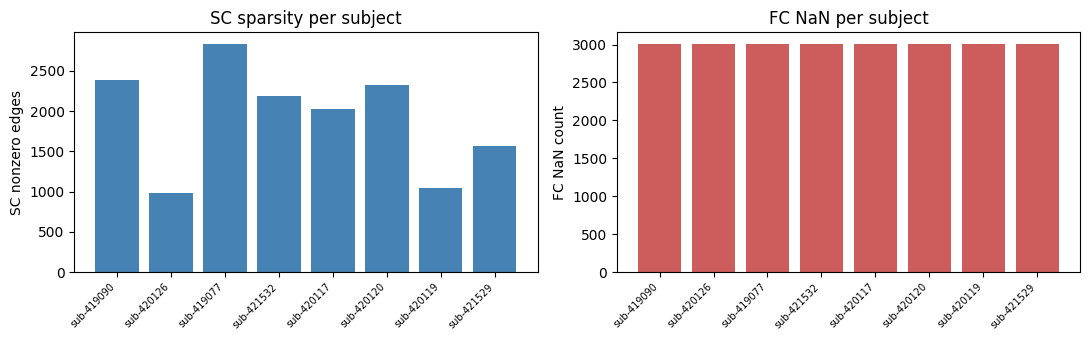

  saved: ./output_mouse_mptp/step1_subjects.png


In [3]:
df, fc_mat, sc_mat, fc_ids, sc_ids, bold_mat, bold_ids = (
    data_loader.load_raw_data()
)
subjects = data_loader.get_target_subjects(df, fc_ids, sc_ids)
train, val, test = data_loader.three_way_split(subjects)

subject_data = data_loader.load_all_subjects(
    train + val + test,
    fc_mat, sc_mat, fc_ids, sc_ids,
    bold_mat, bold_ids,
)

# Result
evaluate.report_step1(train, val, test, subject_data)


## Train data: weights / tract lengths / empirical FC

Step 1 직후 실행. Train subject 4명의 SC(weights), SC tract length, empirical FC를 로드하고 출력합니다.

  sub-419090:  SC=[0.1064, 1.0000]  length=[1.0, 15.6]mm  delay=[0.32, 5.19]ms  FC=[-0.658, 0.879]  SC_nnz=2388
  sub-420126:  SC=[0.1023, 1.0000]  length=[1.0, 10.8]mm  delay=[0.32, 3.60]ms  FC=[-0.770, 0.918]  SC_nnz=982
  sub-419077:  SC=[0.1008, 1.0000]  length=[1.0, 20.8]mm  delay=[0.32, 6.94]ms  FC=[-0.824, 0.936]  SC_nnz=2836
  sub-421532:  SC=[0.1107, 1.0000]  length=[1.0, 14.6]mm  delay=[0.32, 4.87]ms  FC=[-0.457, 0.885]  SC_nnz=2190
  sub-420117:  SC=[0.1028, 1.0000]  length=[1.0, 10.2]mm  delay=[0.32, 3.41]ms  FC=[-0.754, 0.859]  SC_nnz=2026
  sub-420120:  SC=[0.1033, 1.0000]  length=[1.0, 15.0]mm  delay=[0.32, 5.01]ms  FC=[-0.678, 0.961]  SC_nnz=2326


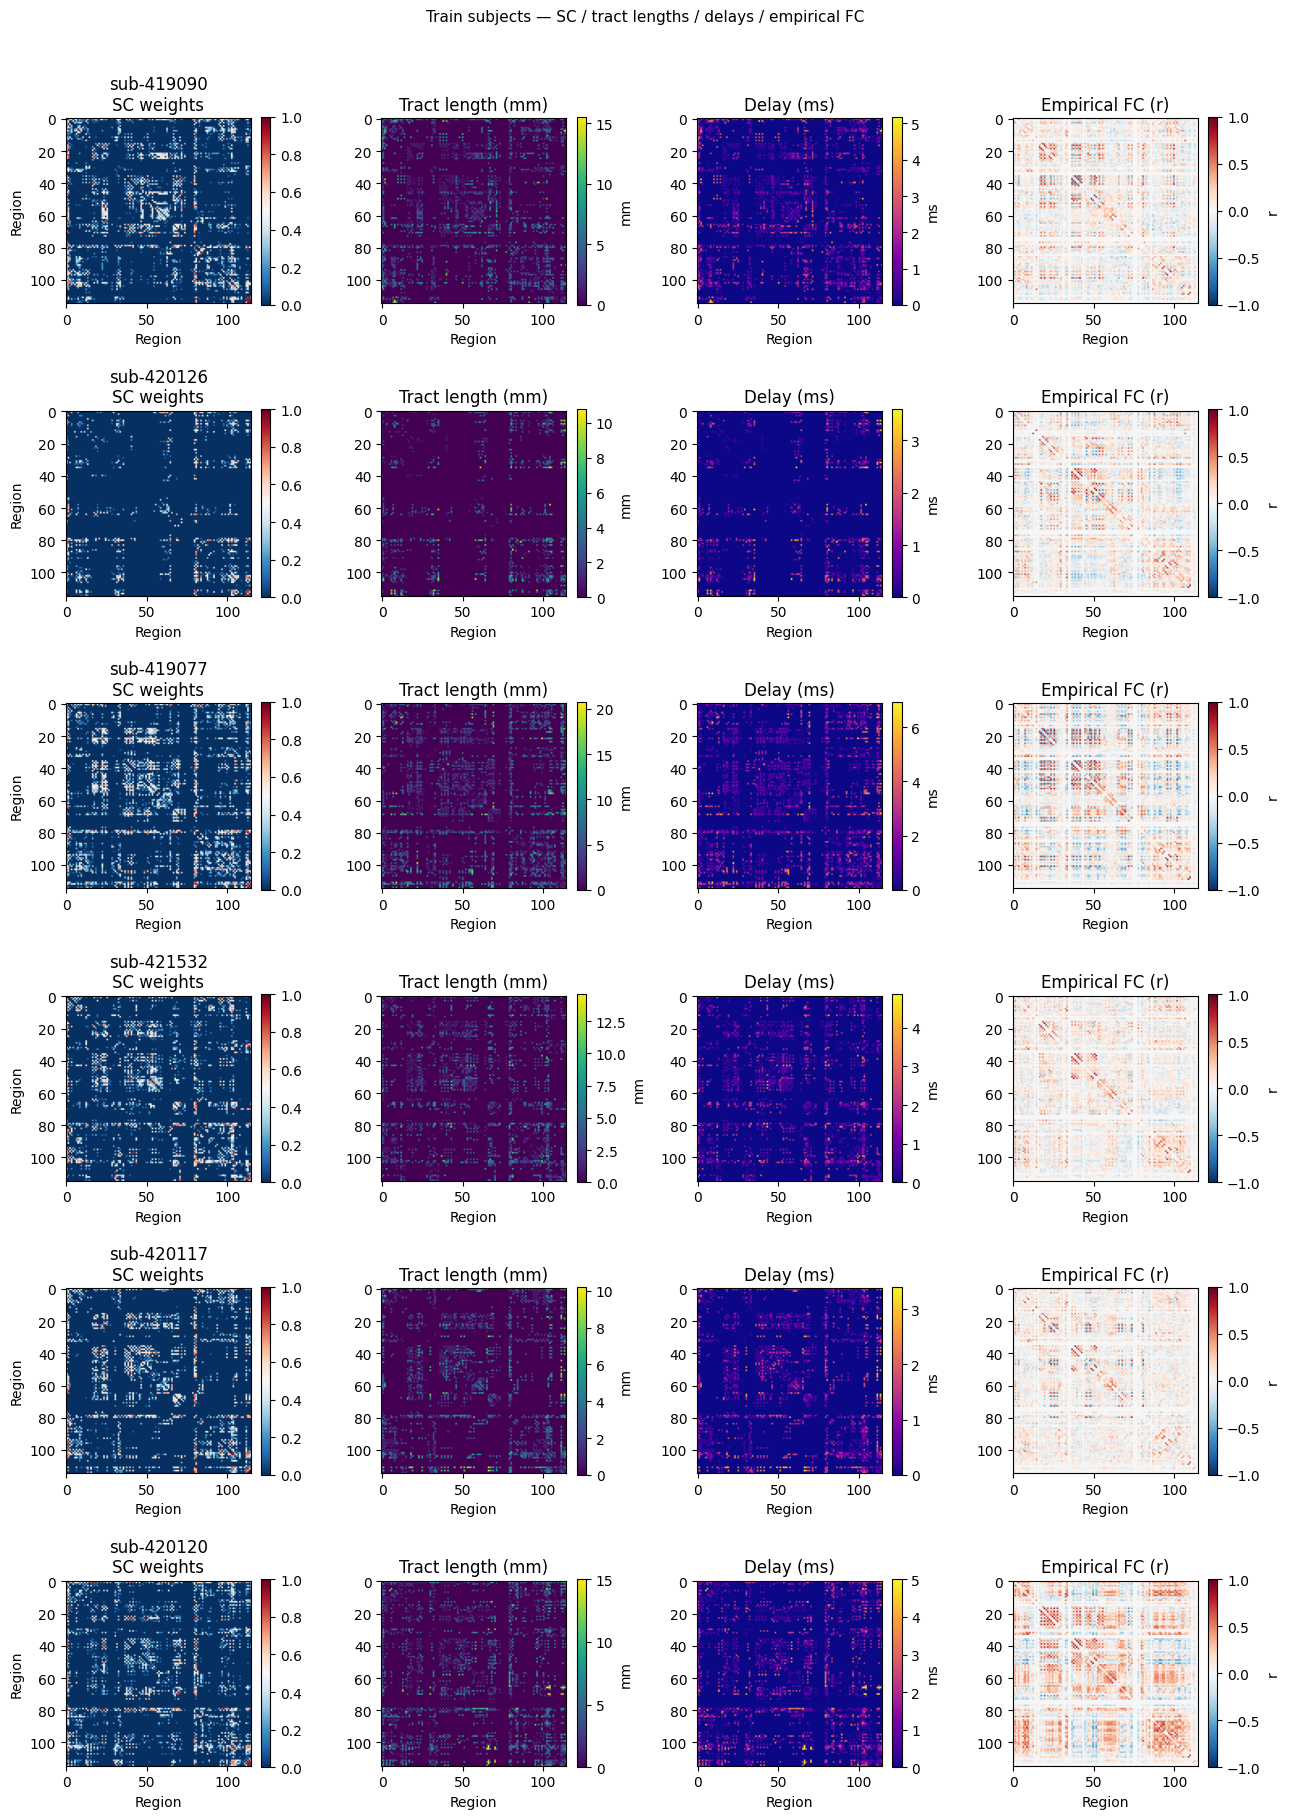

  saved: ./output_mouse_mptp/train_data_matrices.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt

for sid in train:
    d  = subject_data[sid]
    w  = d["sc"].astype(np.float32)
    lm = d["lengths_mm"].astype(np.float32)
    dl = d["delays"].astype(np.float32)
    fc = d["fc"].astype(np.float32)

    w_pos  = w[w > 0]
    lm_pos = lm[lm > 0]
    dl_pos = dl[dl > 0]
    fc_off = fc[np.eye(fc.shape[0]) == 0]

    print(
        f"  {sid}:"
        f"  SC=[{w_pos.min():.4f}, {w_pos.max():.4f}]"
        f"  length=[{lm_pos.min():.1f}, {lm_pos.max():.1f}]mm"
        f"  delay=[{dl_pos.min():.2f}, {dl_pos.max():.2f}]ms"
        f"  FC=[{fc_off.min():.3f}, {fc_off.max():.3f}]"
        f"  SC_nnz={int((w > 0).sum())}"
    )

n_train = len(train)
fig, axes = plt.subplots(n_train, 4,
                         figsize=(13, 3.0 * n_train),
                         squeeze=False)

for row, sid in enumerate(train):
    d  = subject_data[sid]
    w  = d["sc"].astype(np.float32)
    lm = d["lengths_mm"].astype(np.float32)
    dl = d["delays"].astype(np.float32)
    fc = d["fc"].astype(np.float32)

    im0 = axes[row, 0].imshow(w, cmap="RdBu_r", vmin=0, vmax=1)
    axes[row, 0].set_title(f"{sid}\nSC weights")
    axes[row, 0].set_ylabel("Region")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)

    im1 = axes[row, 1].imshow(lm, cmap="viridis")
    axes[row, 1].set_title("Tract length (mm)")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, label="mm")

    im2 = axes[row, 2].imshow(dl, cmap="plasma")
    axes[row, 2].set_title("Delay (ms)")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, label="ms")

    im3 = axes[row, 3].imshow(fc, cmap="RdBu_r", vmin=-1, vmax=1)
    axes[row, 3].set_title("Empirical FC (r)")
    plt.colorbar(im3, ax=axes[row, 3], fraction=0.046, label="r")

for ax in axes.flat:
    ax.set_xlabel("Region")

plt.suptitle(
    "Train subjects — SC / tract lengths / delays / empirical FC",
    fontsize=11, y=1.01,
)
plt.tight_layout()
save_path = "./output_mouse_mptp/train_data_matrices.png"
plt.savefig(save_path, dpi=110, bbox_inches="tight")
plt.show()
print(f"  saved: {save_path}")

## Step 7. Parameter preprocessing ([-1, 1] scaling)

Step 7 runs before step 2 because the simulation needs `prior_scaled` to sample parameters.

In [5]:
param_scaler, prior_scaled = inference.step7_fit_param_scaler(
    verbose=True
)

# Result
evaluate.report_step7(param_scaler)



  [Step 7] Parameter scaling ([-1, 1])
    P      : [0.0, 3.0] -> [-1, 1]
    Q      : [0.0, 3.0] -> [-1, 1]
    g_e    : [0.0, 1.0] -> [-1, 1]
    g_i    : [0.0, 1.0] -> [-1, 1]
    c_ei   : [6.0, 18.0] -> [-1, 1]

  Step 7 result
  Prior bounds:
    P      : [  0.000,   3.000]  -> [-1, 1]
    Q      : [  0.000,   3.000]  -> [-1, 1]
    g_e    : [  0.000,   1.000]  -> [-1, 1]
    g_i    : [  0.000,   1.000]  -> [-1, 1]
    c_ei   : [  6.000,  18.000]  -> [-1, 1]


## Step 2. WC simulation

Feature extraction (step 3) is interleaved inside this loop.

In [ ]:
import os

diag_bold = None
diag_sid = None

_feat_path = os.path.join(config.OUTPUT_DIR, "features_stage1.npz")
if os.path.exists(_feat_path):
    print(f"  [Step 2 skip] loading saved features: {_feat_path}")
    _loaded = inference.load_extracted_features(
        save_dir=config.OUTPUT_DIR, tag="stage1"
    )
    theta_scaled = _loaded["theta_scaled"]
    theta_raw    = _loaded["theta_raw"]
    fc_raw       = _loaded["fc_raw"]
    fcd_raw      = _loaded["fcd_raw"]
else:
    _result = inference.step2_simulate_train(
        train, subject_data, prior_scaled, param_scaler,
        n_sim=config.N_SIM, apply_bw=True, verbose=True,
        save_first_sample=True,
        engine="cubnm",   # Step 2 simulation backend: cuBNM WCVBI
    )
    theta_scaled = _result["theta_scaled"]
    theta_raw    = _result["theta_raw"]
    fc_raw       = _result["fc_raw"]
    fcd_raw      = _result["fcd_raw"]
    diag_bold    = _result.get("diag_bold")
    diag_sid     = _result.get("diag_sid")

evaluate.report_step2(theta_scaled, fc_raw, fcd_raw)

  [14:12:28] [Step 2] WC simulation  N_SIM=10000  subjects=6
    config: GPU_BATCH=10000  T_end=300000ms  T_cut=60000ms  dt=0.5ms
            n_steps=600000  T_bold=240  N=115
            params: P, Q, g_e, g_i, c_ei
  [Step 2] simulation engine: cubnm
  Training data collection: 6 subjects x 10000 = 60000 sims

[Step 2] Subject 1/6  sub-419090  N_SIM=10,000  GPU_BATCH=10,000
         sc_sparsity=0.181  delay_max=5.2ms  n_chunks=1
[cuBNM.simulate] WARNING: conduction delays are not yet mapped onto cuBNM (sc_dist); running WCVBI WITHOUT delays.
[cuBNM-WCVBI] sub-419090: running 10,000 sims (of 10,000) on GPU ...


### Step 2 진단: train subject 1명의 시뮬 결과 시각화

feature extraction 루프에서 캐싱한 첫 번째 시뮬 BOLD/FC를 재시뮬 없이 그대로 그립니다.

# if diag_bold is not None:
    _one_sim = evaluate.plot_one_simulation(
        sid=diag_sid,
        subject_data=subject_data,
        bold=diag_bold,
        sim_idx=0,
    )
else:
    print("  [Step 2 진단] diag_bold 없음 (캐시 로드 경로 또는 시뮬 실패) — 진단 출력 스킵")

## Step 3. Feature extraction summary

Step 2의 streaming loop 안에서 이미 추출된 feature를 정리하고, **raw feature를 디스크에 저장**합니다.

- `fc_raw` : FC upper triangle (Fisher z-transformed)
- `fcd_raw` : FCD upper triangle (element-wise std of sliding-window FCs)

저장 경로: `{OUTPUT_DIR}/features_stage1.npz`  
Load 방법: `inference.load_extracted_features(tag="stage1")`

In [ ]:
import os
inference.step3_summary_features(fc_raw, fcd_raw, verbose=True)

_feat_path = os.path.join(config.OUTPUT_DIR, "features_stage1.npz")
if not os.path.exists(_feat_path):
    inference.save_extracted_features(
        theta_scaled, theta_raw, fc_raw, fcd_raw,
        param_names=config.STAGE1_PARAMS,
        save_dir=config.OUTPUT_DIR,
        tag="stage1",
        verbose=True,
    )
else:
    print(f"  features_stage1.npz exists — skip save")

evaluate.report_step3(fc_raw, fcd_raw)


## Step 4. Feature pipeline (raw FC passthrough)

PCA/z-score 없음. fc_raw (6555) → x_input 그대로.
RegionTransformer가 SNPE-C와 jointly train하면서
attention weight 학습.

In [ ]:
# New pipeline: raw FC is x_input directly
# No PCA, no z-score — RegionTransformer handles feature extraction
from inference.feature_pipeline import FeaturePipeline

feature_pipeline = FeaturePipeline()
# fit() returns self; fit_transform() returns the (n_train, fc_dim) array
x_input = feature_pipeline.fit_transform(fc_raw, fcd_raw, verbose=True)

print(f"  [Step 4] x_input shape : {x_input.shape}")
print(f"  [Step 4] FC raw passthrough — no PCA, no z-score")
print(f"  [Step 4] RegionTransformer will compress during SNPE-C training")

## Step 8. Stage 1 inference (single-round SNPE-C)

In [ ]:
posterior, embedding_net = inference.step8_train_snpe(
    theta_scaled, x_input, prior_scaled,
    verbose=True,
    fc_raw=fc_raw,
    use_embedding=True,
    sc_matrix=subject_data[train[0]]["sc"],
)

s1 = {
    "posterior":        posterior,
    "embedding_net":    embedding_net,
    "theta_scaled":     theta_scaled,
    "theta_raw":        theta_raw,
    "fc_raw":           fc_raw,
    "fcd_raw":          fcd_raw,
    "x_input":          x_input,
    "param_scaler":     param_scaler,
    "feature_pipeline": feature_pipeline,
    "prior_scaled":     prior_scaled,
    "pca_diagnostic":   None,
}

# Result
evaluate.report_step8(posterior, embedding_net, theta_scaled, x_input)

## Phase 3 — Attention Feature Selection
Phase 2에서 학습된 RegionTransformer attention과
posterior gradient를 이용해 파라미터 추론에
중요한 FC edge k=300개를 선택.

In [ ]:
# Phase 3: attention × gradient → top-k FC indices
from inference.stage1 import run_phase2

phase3_result = run_phase2(
    phase1=s1,
    fc_obs=subject_data[train[0]]["fc"],
    k=config.SELECTION_K,
    n_samples=200,
    verbose=True,
)

fc_selected_indices = phase3_result["fc_selected_indices"]
print(f"[Phase 3] 선택된 FC indices: {len(fc_selected_indices)}개")
print(f"  전체 FC 중 {len(fc_selected_indices)/config.FC_DIM*100:.1f}%")

# 중요도 맵 저장
s1["fc_selected_indices"] = fc_selected_indices

## Phase 4 — 2차 SBI (Final Posterior)
선택된 k개 FC feature로 RegionTransformer + SNPE-C 재학습.
value+mask input으로 zero-fill ambiguity 해결.

In [ ]:
# Phase 4: FC(k) + mask → RegionTransformer → SNPE-C
from inference.stage1 import run_phase3

phase4_result = run_phase3(
    phase1=s1,
    fc_selected_indices=fc_selected_indices,
    sc_matrix=subject_data[train[0]]["sc"],
    verbose=True,
)

posterior_2    = phase4_result["posterior"]
embedding_net2 = phase4_result["embedding_net"]

print(f"[Phase 4] 완료")
print(f"  입력: FC({len(fc_selected_indices)}) + mask")
print(f"  시뮬 재실행: 없음 (Phase 1 데이터 재사용)")
print(f"  theta: {phase4_result['theta_scaled'].shape}")
print(f"  fc:    {phase4_result['fc_raw'].shape}")

s2 = {
    "posterior":           posterior_2,
    "embedding_net":       embedding_net2,
    "fc_selected_indices": fc_selected_indices,
    "theta_scaled":        s1["theta_scaled"],
    "theta_raw":           s1["theta_raw"],
    "fc_raw":              s1["fc_raw"],
    "param_scaler":        s1["param_scaler"],
    "prior_scaled":        s1["prior_scaled"],
}

## Phase 2/4 분석 지표
posterior shrinkage, spatial parameter map,
prior predictive vs posterior predictive 비교.

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from features.fc import fc_to_upper_tri

# ── 1. Posterior 샘플링 (Phase2: raw FC, Phase4: selected FC) ──
n_samples = config.N_POSTERIOR
fc_obs_0  = subject_data[train[0]]["fc"]
fc_vec_0  = fc_to_upper_tri(fc_obs_0)

samples_1 = posterior.sample(
    (n_samples,),
    x=torch.tensor(fc_vec_0, dtype=torch.float32
        ).unsqueeze(0).to(config.SBI_DEVICE),
    show_progress_bars=False,
    reject_outside_prior=False,
).detach().cpu().numpy()

fc_vec_k  = fc_vec_0[fc_selected_indices]
samples_2 = posterior_2.sample(
    (n_samples,),
    x=torch.tensor(fc_vec_k, dtype=torch.float32
        ).unsqueeze(0).to(config.SBI_DEVICE),
    show_progress_bars=False,
    reject_outside_prior=False,
).detach().cpu().numpy()

# scaled prior std = 1 (BoxUniform[-1,1])
prior_std = 1.0
shrink_1 = 1 - (samples_1.std(axis=0) / prior_std) ** 2
shrink_2 = 1 - (samples_2.std(axis=0) / prior_std) ** 2

# ── 2. Shrinkage 요약 (global scalars) ──
print("\n[Shrinkage]")
names = config.STAGE1_PARAMS
def _per(s):
    return "  ".join(f"{n}={v:.3f}" for n, v in zip(names, s))
print(f"  Phase 2 mean: {shrink_1.mean():.3f}  ({_per(shrink_1)})")
print(f"  Phase 4 mean: {shrink_2.mean():.3f}  ({_per(shrink_2)})")

# ── 3. 복원된 파라미터 (posterior mean, raw space) ──
# 전역 스칼라 (P/Q/g_e/g_i/c_ei)
raw_2  = param_scaler.inverse_transform(samples_2)     # (n_samples, P)
mean_2 = raw_2.mean(axis=0)
std_2  = raw_2.std(axis=0)
print("\n[복원된 파라미터 (posterior mean, raw)]")
for n, m, s in zip(config.STAGE1_PARAMS, mean_2, std_2):
    print(f"  {n:5s}: mean={m:.3f}  std={s:.3f}")

# ── 4. Phase 2 vs Phase 4 posterior 분포 비교 ──
plot_data = [(samples_1[:, i], samples_2[:, i], n)
             for i, n in enumerate(config.STAGE1_PARAMS)]

fig, axes = plt.subplots(1, len(plot_data),
                         figsize=(5 * len(plot_data), 4), squeeze=False)
for ax, (d1, d2, label) in zip(axes[0], plot_data):
    ax.boxplot([d1, d2],
               labels=['Phase2\n(raw FC)', 'Phase4\n(selected FC)'])
    ax.set_title(label)
    ax.set_ylabel('scaled value')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
plt.suptitle('Posterior distribution: Phase2 vs Phase4')
plt.tight_layout()
plt.savefig(
    f"{config.OUTPUT_DIR}/phase2_vs_phase4_posterior.png",
    dpi=110, bbox_inches='tight'
)
plt.show()
print("[저장] phase2_vs_phase4_posterior.png")


## Step 9. Stage 1 analysis (validation)

9a validation metrics · 9b baseline · 9c MLP probing · 9d SBC · 9e posterior plots

In [ ]:
s1_val_results, stage1_agg = evaluate.evaluate_validation_stage1(
    val, subject_data, s1, apply_bw=True, verbose=True,
)

baseline_agg = evaluate.baseline_eval_subjects(
    val, subject_data, n_resim=10, verbose=True,
)

inference.evaluate_embedding_probing(
    s1["embedding_net"], s1["theta_scaled"],
    s1["x_input"], config.STAGE1_PARAMS, verbose=True,
)

sbc_ranks = inference.simulation_based_calibration(
    s1["posterior"], s1["prior_scaled"], s1["param_scaler"],
    s1["feature_pipeline"], config.STAGE1_PARAMS,
    weights=subject_data[train[0]]["sc"],
    delays=subject_data[train[0]]["delays"],
    n_sbc=config.N_SBC, n_posterior=1000,
)
evaluate.plot_sbc_rank_histogram(sbc_ranks, config.STAGE1_PARAMS)
evaluate.plot_posteriors(
    stage1_agg["per_subject"],
    config.STAGE1_PARAMS,
    config.STAGE1_PRIOR_LOW,
    config.STAGE1_PRIOR_HIGH,
    title="Stage 1",
)

# Result
evaluate.report_step9(stage1_agg, baseline_agg)


# ── Phase 4 (posterior_2) validation ─────────────────────
# evaluate_validation_stage1 feeds full 6555-dim FC; posterior_2
# expects k-selected (300-dim). Wrap the pipeline so .transform()
# slices to fc_selected_indices before posterior.sample.
class _SlicedPipeline:
    def __init__(self, pipe, idx):
        self.pipe, self.idx = pipe, idx
    def transform(self, fc, fcd=None):
        x = self.pipe.transform(fc, fcd)
        return x[:, self.idx]

s2_eval = dict(
    s2,
    feature_pipeline=_SlicedPipeline(
        s1["feature_pipeline"], fc_selected_indices,
    ),
)
s2_val_results, stage2_agg = evaluate.evaluate_validation_stage1(
    val, subject_data, s2_eval, apply_bw=True, verbose=True,
)
evaluate.report_step9(stage2_agg, baseline_agg)

In [ ]:
config.N_SBC = 20
sbc_ranks = inference.simulation_based_calibration(
    s1["posterior"], s1["prior_scaled"], s1["param_scaler"],
    s1["feature_pipeline"], config.STAGE1_PARAMS,
    weights=subject_data[train[0]]["sc"],
    delays=subject_data[train[0]]["delays"],
    n_sbc=20, n_posterior=200,
)
evaluate.plot_sbc_rank_histogram(sbc_ranks, config.STAGE1_PARAMS)
evaluate.plot_posteriors(
    stage1_agg["per_subject"], config.STAGE1_PARAMS,
    config.STAGE1_PRIOR_LOW, config.STAGE1_PRIOR_HIGH, title="Stage 1",
)
evaluate.report_step9(stage1_agg, baseline_agg)


## Step 13. Model selection (validation)

In [ ]:
best_stage, scores = evaluate.select_best_model(
    stage1_agg, stage2_agg=None, baseline_agg=None, verbose=True,
)
score_1 = scores["stage1"]
score_2 = scores["stage2"]

# Result
evaluate.report_step13(best_stage, score_1, score_2, stage1_agg, None)

## Step 14. Final test

In [ ]:
test_summary = evaluate.final_test(
    test, subject_data, best_stage, s1, None,
    n_resim=config.N_TEST_RESIM, apply_bw=True, verbose=True,
)
evaluate.plot_fc_comparison(
    test_summary["per_subject"],
    save_path=os.path.join(config.OUTPUT_DIR, "test_fc_comparison.png"),
    title=f"Test FC (Stage {best_stage})",
)

# Result
evaluate.report_step14(test_summary)

## Save outputs and summary

In [ ]:
inference.save_artifacts(
    os.path.join(config.OUTPUT_DIR, "artifacts.pkl"),
    stage1_param_scaler     = s1["param_scaler"].to_dict(),
    stage1_feature_pipeline = s1["feature_pipeline"],
    stage1_pca_diagnostic   = s1["pca_diagnostic"],
    best_stage              = best_stage,
    n_regions               = config.N_REGIONS,
    fc_dim                  = config.FC_DIM,
    prior_low               = config.STAGE1_PRIOR_LOW,
    prior_high              = config.STAGE1_PRIOR_HIGH,
    param_names_s1          = config.STAGE1_PARAMS,
    feature_config          = {
        "pca_dim_fc":  (
            s1["feature_pipeline"].fc_pca.n_components
            if s1["feature_pipeline"].fc_pca is not None else None
        ),
        "pca_dim_fcd": None,
    },
)

torch.save(
    s1["embedding_net"].state_dict(),
    os.path.join(config.OUTPUT_DIR, "embedding_net_s1.pt"),
)

evaluate.print_final_summary(
    stage1_agg, None, best_stage, test_summary,
    train, len(s1["theta_scaled"]),
)